In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install diffusers transformers accelerate peft safetensors bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

# Load the Pretrained Model

In [ ]:
import torch
from diffusers import StableDiffusionXLPipeline

base_model = "stabilityai/stable-diffusion-xl-base-1.0"
pipe = StableDiffusionXLPipeline.from_pretrained(base_model, torch_dtype=torch.float16)
pipe.to("cuda")

print("Base Model Loaded!")


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/479 [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Base Model Loaded!


In [ ]:
torch.cuda.is_available()


True

In [ ]:
pipe.load_lora_weights("artificialguybr/StickersRedmond", weight_name="StickersRedmond.safetensors")
print("LoRA Weights Loaded!")


LoRA Weights Loaded!


# Generate a Sticker

In [ ]:
prompt = "A cute real cat holding a pet, colorful sticker style"
result = pipe(prompt, height=512, width=512, num_inference_steps=20, guidance_scale=5).images[0]

  0%|          | 0/20 [00:00<?, ?it/s]

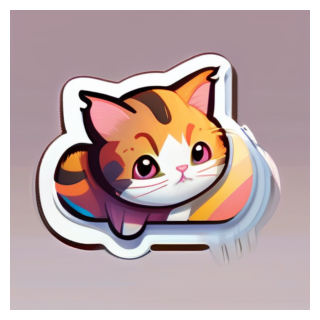

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(3, 3))  # Set figure size
plt.imshow(result)  # Show the generated image
plt.axis('off')  # Remove axes for a cleaner view
plt.tight_layout(pad=0)  # Remove extra padding
plt.show()


In [ ]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Check trainable parameters in U-Net
unet_trainable_params = count_trainable_params(pipe.unet)

# Check trainable parameters in Text Encoder
text_encoder_trainable_params = count_trainable_params(pipe.text_encoder)

print(f"Trainable Parameters in U-Net: {unet_trainable_params}")
print(f"Trainable Parameters in Text Encoder: {text_encoder_trainable_params}")


Trainable Parameters in U-Net: 85114880
Trainable Parameters in Text Encoder: 123060480


In [ ]:
!pip install bitsandbytes transformers diffusers --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 78.9 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.48.3
    Uninstalling transformers-4.48.3:
      Successfully uninstalled transformers-4.48.3


In [ ]:
from diffusers import StableDiffusionXLPipeline
from transformers import BitsAndBytesConfig
import torch


In [ ]:
from diffusers import StableDiffusionXLPipeline
from transformers import BitsAndBytesConfig
import torch

# Base Model Name
base_model = "stabilityai/stable-diffusion-xl-base-1.0"

# 4-bit Quantization Configuration
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"  # Non-Float 4 type
)

# Load Model with Quantization
pipe = StableDiffusionXLPipeline.from_pretrained(
    base_model,
    torch_dtype=torch.float16,
    quantization_config=bnb_config
).to("cuda")

# Load LoRA Weights
pipe.load_lora_weights("artificialguybr/StickersRedmond", weight_name="StickersRedmond.safetensors")

print("Model Loaded with 4-bit Quantization!")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Keyword arguments {'quantization_config': BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "float16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": false,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbyt

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Model Loaded with 4-bit Quantization!


# DATASETS CHECKING

In [ ]:
import os
import json

# Paths
image_folder = "/content/drive/MyDrive/AIP_Project/week 7 /Datasets/images_preprocessed"
json_path = "/content/drive/MyDrive/AIP_Project/week 7 /Datasets/preprocessed_text_cleaned (1).json"

# Load JSON file
with open(json_path, "r") as f:
    dataset = json.load(f)

# Get total counts
total_images = len(os.listdir(image_folder))
total_text_entries = len(dataset)

# Print dataset status
print(f"Final Dataset Check Passed!")
print(f"Total Images Available: {total_images}")
print(f"Total Text Entries Available: {total_text_entries}")

# Confirm all entries match
if total_images >= total_text_entries:
    print(" Perfect Match! Ready for training!")
else:
    print(" WARNING: Image and text counts do not match. Double-check your dataset.")

Final Dataset Check Passed!
Total Images Available: 2671
Total Text Entries Available: 2151
 Perfect Match! Ready for training!


In [ ]:
import json

# Paths to dataset
json_path = "/content/drive/MyDrive/AIP_Project/week 7 /Datasets/preprocessed_text_cleaned (1).json"

# Load JSON file
with open(json_path, "r") as f:
    sticker_dataset = json.load(f)

print(f"✅ Loaded {len(sticker_dataset)} sticker samples!")

✅ Loaded 2151 sticker samples!


In [ ]:
# Paths to dataset
image_folder = "/content/drive/MyDrive/AIP_Project/week 7 /Datasets/images_preprocessed"
json_path = "/content/drive/MyDrive/AIP_Project/week 7 /Datasets/preprocessed_text_cleaned (1).json"

# Load JSON file
with open(json_path, "r") as f:
    sticker_dataset = json.load(f)

print(f"✅ Loaded {len(sticker_dataset)} sticker samples!")

✅ Loaded 2151 sticker samples!


# Define the Dataset Class

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import AutoencoderKL
import torch
import os

class StickerDataset(Dataset):
    def __init__(self, dataset, image_folder, tokenizer, text_encoder, vae, max_seq_length=50):
        self.dataset = dataset
        self.image_folder = image_folder
        self.tokenizer = tokenizer
        self.text_encoder = text_encoder
        self.vae = vae
        self.max_seq_length = max_seq_length

        # ✅ Keep image size at 128x128 to reduce memory usage
        self.image_transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        # ✅ Load and encode text directly (handle missing keys)
        text = sample.get("text")
        if not text:
            # Skip sample if text is missing
            return self.__getitem__((idx + 1) % len(self.dataset))

        tokens = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_seq_length,
            return_tensors="pt"
        ).to("cuda")

        with torch.no_grad():
            # ✅ Reduce dimensionality for SDXL compatibility
            text_embeddings = self.text_encoder(tokens.input_ids).last_hidden_state.mean(dim=1)

        # ✅ Load and preprocess image
        image_path = os.path.join(self.image_folder, sample.get("image"))
        if not image_path or not os.path.exists(image_path):
            # Skip sample if image file is missing
            return self.__getitem__((idx + 1) % len(self.dataset))

        image = Image.open(image_path).convert("RGB")
        image_tensor = self.image_transform(image).unsqueeze(0).to("cuda")

        # ✅ Encode image into latent space using VAE
        with torch.no_grad():
            latents = self.vae.encode(image_tensor).latent_dist.sample().squeeze(0) * 0.18215
            latents = latents.cpu()

        # ✅ Generate a random timestep
        timestep = torch.randint(0, 1000, (1,))

        return {
            "sample": latents,
            "timestep": timestep,
            "encoder_hidden_states": text_embeddings.squeeze(0).cpu()
        }


In [ ]:
from torch.utils.data import DataLoader

# Load tokenizer, text encoder, and VAE
tokenizer = CLIPTokenizer.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", subfolder="text_encoder").to("cuda")
vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae").to("cuda")

# Create dataset object
sticker_dataset = StickerDataset(
    dataset=sticker_dataset,
    image_folder=image_folder,
    tokenizer=tokenizer,
    text_encoder=text_encoder,
    vae=vae
)

# Define DataLoader
train_dataloader = DataLoader(
    sticker_dataset,
    batch_size=4,               # Adjust based on available GPU memory
    shuffle=True,               # Shuffle for better training
    pin_memory=True,            # Keep data in pinned memory for faster GPU access
    num_workers=2,              # Adjust based on CPU cores
    persistent_workers=True     # Keep workers alive for faster loading
)

print(f"DataLoader Created! Total Batches: {len(train_dataloader)}")

DataLoader Created! Total Batches: 538


In [ ]:
import torch.multiprocessing as mp
mp.set_start_method("spawn", force=True)


DAta_Loader

In [ ]:
from torch.utils.data import DataLoader

#  Create Dataset Object
sticker_dataset = StickerDataset(
    dataset=sticker_dataset,
    image_folder=image_folder,
    tokenizer=tokenizer,
    text_encoder=text_encoder,
    vae=vae
)

# Define DataLoader
train_dataloader = DataLoader(
    sticker_dataset,
    batch_size=2,  # Adjust based on GPU capacity
    shuffle=True,
    pin_memory=True,
    num_workers=0,  # Disable multiprocessing to avoid CUDA conflict
    persistent_workers=False
)

print(f"DataLoader Created! Total Batches: {len(train_dataloader)}")

DataLoader Created! Total Batches: 1076


# Training Loop

In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

# ✅ Set model to training mode
pipe.unet.train()

# ✅ Define optimizer
optimizer = torch.optim.AdamW(pipe.unet.parameters(), lr=5e-5)

num_epochs = 10
print("✅ Starting Fine-Tuning...")

for epoch in range(num_epochs):
    total_loss = 0
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{num_epochs}")

    for batch in progress_bar:
        optimizer.zero_grad()

        try:
            # ✅ Load batch to GPU
            latents = batch["sample"].to("cuda").to(torch.float16)
            timesteps = batch["timestep"].squeeze(-1).to("cuda")
            encoder_hidden_states = batch["encoder_hidden_states"].to("cuda").to(torch.float16)

            # ✅ Add noise to the latent vectors
            noise = torch.randn_like(latents, dtype=torch.float16)
            noisy_latents = latents + noise * 0.1

            # ✅ Prepare time_ids for SDXL
            time_ids = torch.zeros((latents.shape[0], 6), device=latents.device, dtype=latents.dtype)

            # ✅ Reduce text embeddings to match input shape
            text_embeds = encoder_hidden_states.mean(dim=1)

            # ✅ Predict noise using U-Net (with text_embeds + time_ids)
            predicted_noise = pipe.unet(
                noisy_latents,
                timesteps,
                encoder_hidden_states=encoder_hidden_states,
                added_cond_kwargs={
                    "text_embeds": text_embeds,
                    "time_ids": time_ids
                }
            ).sample

            # ✅ Compute Mean Squared Error (MSE) loss
            loss = F.mse_loss(predicted_noise, noise)
            loss.backward()
            optimizer.step()

            # ✅ Update progress bar
            total_loss += loss.item()
            progress_bar.set_postfix({"Loss": loss.item()})

        except Exception as e:
            print(f"❌ Skipping sample due to error: {e}")
            continue

    avg_loss = total_loss / len(train_dataloader)
    print(f"✅ Epoch {epoch + 1} Complete! Average Loss: {avg_loss:.4f}")

print("✅ Fine-Tuning Complete!")


✅ Starting Fine-Tuning...


Epoch 1/10:   0%|          | 0/1076 [00:00<?, ?it/s]


KeyError: 'text'

In [ ]:
print(sticker_dataset[0])  # Check actual keys in the dataset


KeyError: 'text'

In [ ]:
with open(json_path, "r") as f:
    sticker_dataset = json.load(f)


In [ ]:
print(sticker_dataset[0])


{'image': 'emoji_0.png', 'text': '<|startoftext|>🌍 news update : grinning _ face is making headlines today ! <|endoftext|>'}
